In [99]:
p = 90
N = 30
CIRCLES_SCALER = 1

# Batch sizes for comparison
BATCH_SIZES = {
    "conservative": [3, 5, 15],
    "physbo": [1]
}
trial_list = [1, 2, 3, 4, 5]

In [100]:
import pickle

import networkx as nx
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 15
import numpy as np

from collections import defaultdict
from pathlib import Path
from sklearn.metrics.pairwise import pairwise_distances
from tqdm.asyncio import tqdm
from string import Template
from joblib import Parallel, delayed
# from descriptor import Desctiptor
from al_mg_zn import AlMgZnMeltingPoint
des = AlMgZnMeltingPoint()

def maximal_independent_set(D, t):
    adj_matrix = np.array(D <= t, dtype=int)
    np.fill_diagonal(adj_matrix, 0)
    G = nx.from_numpy_array(np.array(adj_matrix))
    return nx.maximal_independent_set(G)

def calc_circles(X, radius):
    X = np.array(X)
    # print(X.shape, radius)
    D = pairwise_distances(X, metric="euclidean")
    s = maximal_independent_set(D, radius)
    return len(s)

def get_circles(X, action_idx, threshold_list):
    """並列化されたバージョン - joblibのスレッド並列化を使用"""
    return Parallel(n_jobs=-1, backend='threading')(
        delayed(calc_circles)(X, action_idx, t) for t in threshold_list)

def get_circles_process_parallel(X, action_idx, threshold_list):
    """プロセス並列化バージョン（大きなデータセット用）"""
    return Parallel(n_jobs=-1)(delayed(calc_circles)(X, action_idx, t) for t in threshold_list)

def get_circles_sequential(X, action_idx, threshold_list):
    """元のシーケンシャルバージョン（比較用）"""
    return [calc_circles(X, action_idx, t) for t in threshold_list]

# Directory name's template string - 新しい命名規則
# data_{mode}_batch{batch_size}_trial{trial}
dir_template = Template("data_${MODE}_batch${BATCH_SIZE}_trial${TRIAL}")

radius_list = np.arange(0, 26, 1)

# 比較するメソッド・バッチの組み合わせ (label, mode, batch_size)
method_configs = [
    ("physbo (batch=1)", "physbo", 1),
    ("NTS conservative (batch=3)", "conservative", 3),
    ("NTS conservative (batch=5)", "conservative", 5),
    ("NTS conservative (batch=15)", "conservative", 15),
]

In [101]:
# データ構造の詳細調査と修正されたデータ読み込み


def collect_near_optimal_samples(samples_dict, objectives_dict, target_threshold, iter_num):
    """
    指定されたイテレーション数まで、target_thresholdを超えるサンプルを収集する関数
    
    Parameters:
    -----------
    samples_dict : dict
        各イテレーションのサンプルデータ
    objectives_dict : dict  
        各イテレーションの目的値データ
    target_threshold : float
        閾値
    iter_num : int
        処理するイテレーション数
    
    Returns:
    --------
    dict : 各イテレーションまでの累積near-optimalサンプル
    int : 見つかったnear-optimalサンプルの総数
    """
    near_optimal_samples_by_iter = defaultdict(list)
    # print(samples_dict.keys())
    for k in range(1, len(samples_dict.keys()) + 1):
        # near_optimal_samples_by_iter は各イテレーションまでに見つかったnear-optimal samplesを全て保持
        near_optimal_samples_by_iter[k] = near_optimal_samples_by_iter[k-1].copy()
        for sample, obj in zip(samples_dict[k], objectives_dict[k]):
            if obj >= target_threshold:
                near_optimal_samples_by_iter[k].append(sample)
    
    return near_optimal_samples_by_iter

def circles_by_radius(X, radius_list):
    return [calc_circles(X, r) for r in radius_list]

def all_circles(sample_path, objective_path, target_threshold, N):

    with open(sample_path, 'rb') as f:
        samples_dict = pickle.load(f)

    with open(objective_path, 'rb') as f:
        objectives_dict = pickle.load(f)


    # function = Descriptor()
    near_optimal_samples_by_iter = defaultdict(list)
    # kを1から10まで変化させ、target_thresholdを超えたサンプルを

    # 関数を使用
    near_optimal_samples_by_iter = collect_near_optimal_samples(
        samples_dict, objectives_dict, target_threshold, N
    )
    n = len(near_optimal_samples_by_iter)
    circles = circles_by_radius(near_optimal_samples_by_iter[n-1], radius_list)
    return circles

def all_max_objective(sample_path, objective_path, N):

    with open(sample_path, 'rb') as f:
        samples_dict = pickle.load(f)

    with open(objective_path, 'rb') as f:
        objectives_dict = pickle.load(f)

    max_objective_list = [max(objectives_dict[k]) for k in sorted(list(objectives_dict.keys()))]
    all_max_objective_list = [max_objective_list[0]]
    n = len(max_objective_list)
    for k in range(1, n):
        # print(max_objective_list, max(objectives_dict[k]))
        all_max_objective_list.append(max(all_max_objective_list[-1], max(objectives_dict[k])))
    return all_max_objective_list

# target_threshold は function.y の90パーセンタイルに対応
target_threshold = np.percentile(des.y, p)
print(f"Target threshold for {p}% percentile: {target_threshold}")

Target threshold for 90% percentile: 839.985


In [102]:
# データ読み込み：各メソッド・バッチサイズ組み合わせについてCirclesを計算
method_to_circles = defaultdict(list)
method_to_batch_size = {}

for label, mode, batch_size in method_configs:
    method_to_batch_size[label] = batch_size
    for trial in trial_list:
        data_dir = dir_template.substitute(MODE=mode, BATCH_SIZE=batch_size, TRIAL=trial)
        print(f"Loading data from: {data_dir}")
        sample_path = Path(data_dir) / "sample_by_iter.pkl"
        objective_path = Path(data_dir) / "objective_by_iter.pkl"
        
        if not sample_path.exists():
            print(f"Warning: {sample_path} not found, skipping...")
            continue
            
        circles = all_circles(sample_path, objective_path, target_threshold, N)
        method_to_circles[label].append([c / CIRCLES_SCALER for c in circles])

print("Data loading completed.")
for label in method_to_circles:
    print(f"  {label}: {len(method_to_circles[label])} trials loaded")

Loading data from: data_physbo_batch1_trial1
Loading data from: data_physbo_batch1_trial2
Loading data from: data_physbo_batch1_trial3
Loading data from: data_physbo_batch1_trial4
Loading data from: data_physbo_batch1_trial5
Loading data from: data_conservative_batch3_trial1
Loading data from: data_conservative_batch3_trial2
Loading data from: data_conservative_batch3_trial3
Loading data from: data_conservative_batch3_trial4
Loading data from: data_conservative_batch3_trial5
Loading data from: data_conservative_batch5_trial1
Loading data from: data_conservative_batch5_trial2
Loading data from: data_conservative_batch5_trial3
Loading data from: data_conservative_batch5_trial4
Loading data from: data_conservative_batch5_trial5
Loading data from: data_conservative_batch15_trial1
Loading data from: data_conservative_batch15_trial2
Loading data from: data_conservative_batch15_trial3
Loading data from: data_conservative_batch15_trial4
Loading data from: data_conservative_batch15_trial5
Data 

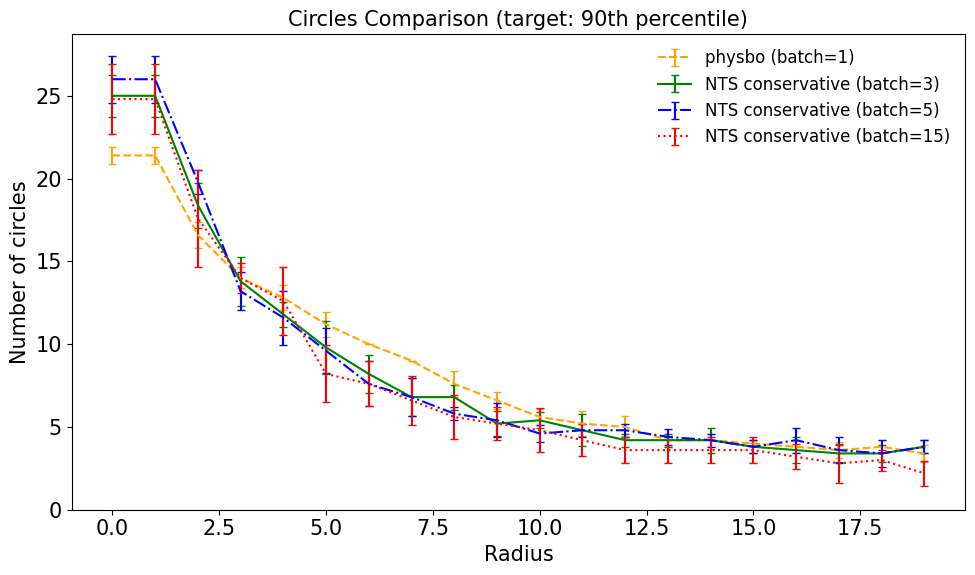

In [103]:
# スタイル設定
method_to_style = {
    "physbo (batch=1)": "--",
    "NTS conservative (batch=3)": "-",
    "NTS conservative (batch=5)": "-.",
    # "NTS conservative (batch=9)": ":",
    "NTS conservative (batch=15)": ":",
}

method_to_color = {
    "physbo (batch=1)": "orange",
    "NTS conservative (batch=3)": "green",
    "NTS conservative (batch=5)": "blue",
    # "NTS conservative (batch=9)": "red",
    "NTS conservative (batch=15)": "red",
}

# Circlesのプロット
fig, ax = plt.subplots(figsize=(10, 6))
for label in method_to_circles:
    if len(method_to_circles[label]) == 0:
        continue
    mean_circles = np.mean(np.array(method_to_circles[label]), axis=0)
    std_circles = np.std(np.array(method_to_circles[label]), axis=0)
    ax.errorbar(radius_list[:20], mean_circles[:20], yerr=std_circles[:20], 
                label=label, linestyle=method_to_style[label], 
                color=method_to_color[label], capsize=3)

ax.set_xlabel("Radius", fontsize=15)
ax.set_ylabel("Number of circles", fontsize=15)
ax.set_title(f"Circles Comparison (target: {p}th percentile)", fontsize=15)
ax.set_ylim(0)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig(f"figures/circles_comparison_batch_sizes_{p}percentile.pdf")
plt.show()

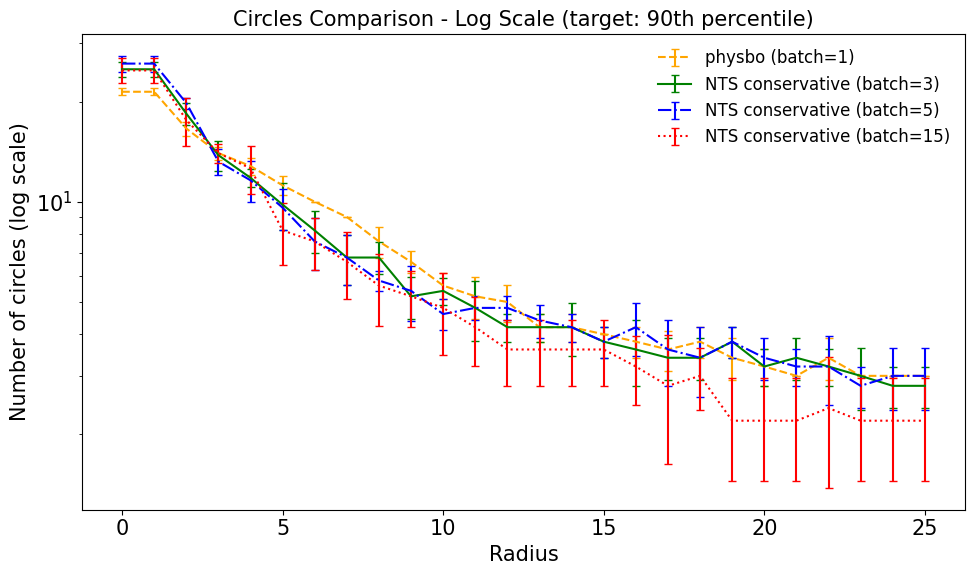

In [104]:
# Circles (log scale)
fig, ax = plt.subplots(figsize=(10, 6))
for label in method_to_circles:
    if len(method_to_circles[label]) == 0:
        continue
    mean_circles = np.mean(np.array(method_to_circles[label]), axis=0)
    std_circles = np.std(np.array(method_to_circles[label]), axis=0)
    ax.errorbar(radius_list, mean_circles, yerr=std_circles, 
                label=label, linestyle=method_to_style[label], 
                color=method_to_color[label], capsize=3)

ax.set_xlabel("Radius", fontsize=15)
ax.set_ylabel("Number of circles (log scale)", fontsize=15)
ax.set_title(f"Circles Comparison - Log Scale (target: {p}th percentile)", fontsize=15)
ax.set_yscale("log")
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig(f"figures/circles_comparison_batch_sizes_{p}percentile_log.pdf")
plt.show()

In [105]:
# Simple regretの計算
method_to_objectives = defaultdict(list)
method_to_regrets = defaultdict(list)

for label, mode, batch_size in method_configs:
    for trial in trial_list:
        data_dir = dir_template.substitute(MODE=mode, BATCH_SIZE=batch_size, TRIAL=trial)
        print(data_dir)
        sample_path = Path(data_dir) / "sample_by_iter.pkl"
        objective_path = Path(data_dir) / "objective_by_iter.pkl"
        # with open(objective_path, 'rb') as f:
        #     objectives_dict = pickle.load(f)
        #     print(objectives_dict)
        
        if not sample_path.exists():
            continue
            
        objectives = all_max_objective(sample_path, objective_path, N)
        method_to_objectives[label].append(objectives)
        method_to_regrets[label].append([des.get_regret(obj) for obj in objectives])

print("Regret data loading completed.")

data_physbo_batch1_trial1
data_physbo_batch1_trial2
data_physbo_batch1_trial3
data_physbo_batch1_trial4
data_physbo_batch1_trial5
data_conservative_batch3_trial1
data_conservative_batch3_trial2
data_conservative_batch3_trial3
data_conservative_batch3_trial4
data_conservative_batch3_trial5
data_conservative_batch5_trial1
data_conservative_batch5_trial2
data_conservative_batch5_trial3
data_conservative_batch5_trial4
data_conservative_batch5_trial5
data_conservative_batch15_trial1
data_conservative_batch15_trial2
data_conservative_batch15_trial3
data_conservative_batch15_trial4
data_conservative_batch15_trial5
Regret data loading completed.


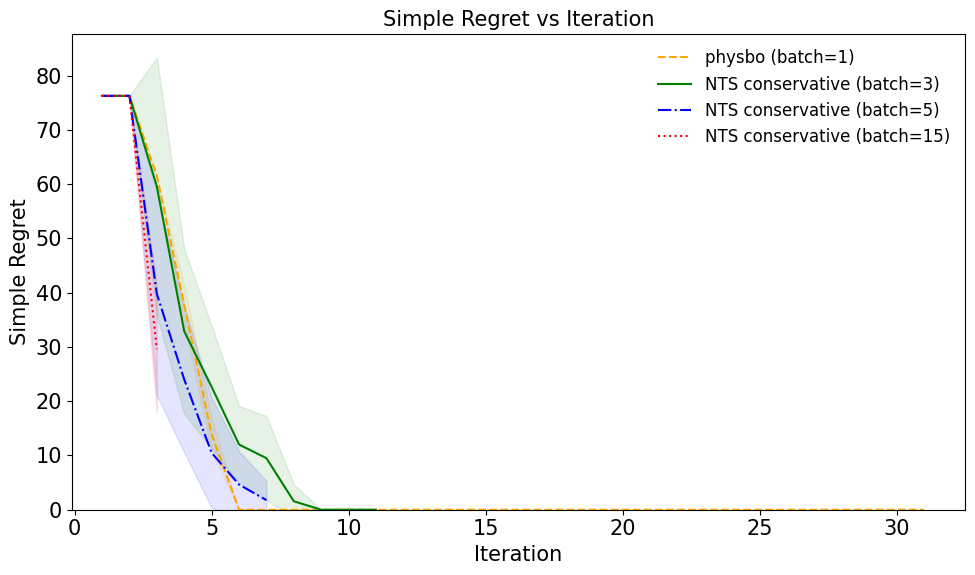

In [106]:
# Simple Regret vs Iteration
fig, ax = plt.subplots(figsize=(10, 6))
for label in method_to_regrets:
    if len(method_to_regrets[label]) == 0:
        continue
    # if label == "NTS conservative (batch=24)":
    #     continue
    mean_regrets = np.mean(np.array(method_to_regrets[label]), axis=0)
    std_regrets = np.std(np.array(method_to_regrets[label]), axis=0)
    iterations = np.arange(1, len(mean_regrets)+1)
    ax.plot(iterations, mean_regrets, label=label, 
            linestyle=method_to_style[label], color=method_to_color[label])
    ax.fill_between(iterations, mean_regrets - std_regrets, 
                    mean_regrets + std_regrets, alpha=0.1, color=method_to_color[label])

ax.set_xlabel("Iteration", fontsize=15)
ax.set_ylabel("Simple Regret", fontsize=15)
ax.set_title("Simple Regret vs Iteration", fontsize=15)
ax.set_xlim(-0.1)
ax.set_ylim(0)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("figures/simple_regret_vs_iteration.pdf")
plt.show()

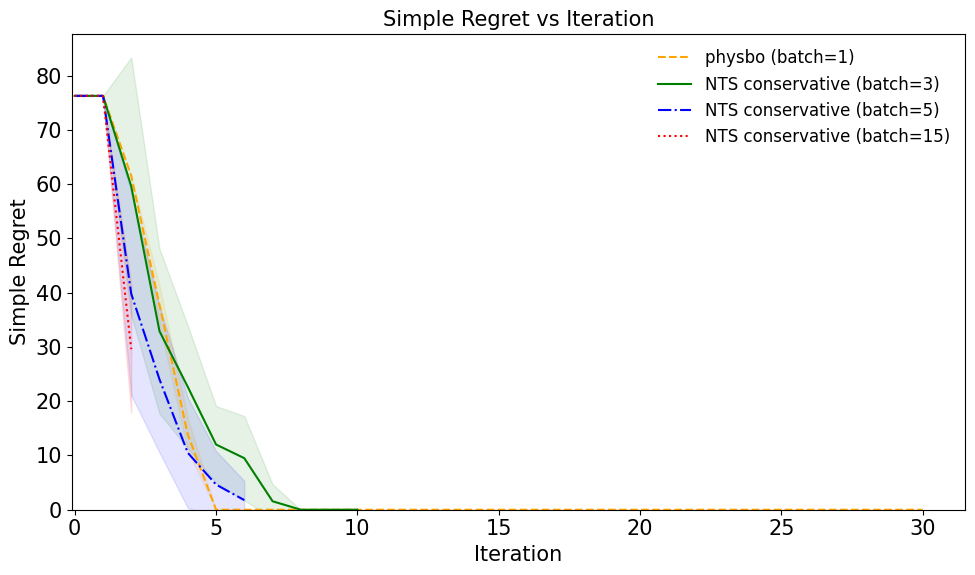

In [107]:
# Simple Regret vs Iteration
fig, ax = plt.subplots(figsize=(10, 6))
for label in method_to_regrets:
    if len(method_to_regrets[label]) == 0:
        continue
    if label == "NTS conservative (batch=24)":
        continue
    mean_regrets = np.mean(np.array(method_to_regrets[label]), axis=0)
    std_regrets = np.std(np.array(method_to_regrets[label]), axis=0)
    iterations = np.arange(len(mean_regrets))
    ax.plot(iterations, mean_regrets, label=label, 
            linestyle=method_to_style[label], color=method_to_color[label])
    ax.fill_between(iterations, mean_regrets - std_regrets, 
                    mean_regrets + std_regrets, alpha=0.1, color=method_to_color[label])

ax.set_xlabel("Iteration", fontsize=15)
ax.set_ylabel("Simple Regret", fontsize=15)
ax.set_title("Simple Regret vs Iteration", fontsize=15)
ax.set_xlim(-0.1)
ax.set_ylim(0)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("figures/simple_regret_vs_iteration.pdf")
plt.show()

physbo (batch=1): expanded_regrets.shape = (5, 45)
NTS conservative (batch=3): expanded_regrets.shape = (5, 45)
NTS conservative (batch=5): expanded_regrets.shape = (5, 45)
NTS conservative (batch=15): expanded_regrets.shape = (5, 45)


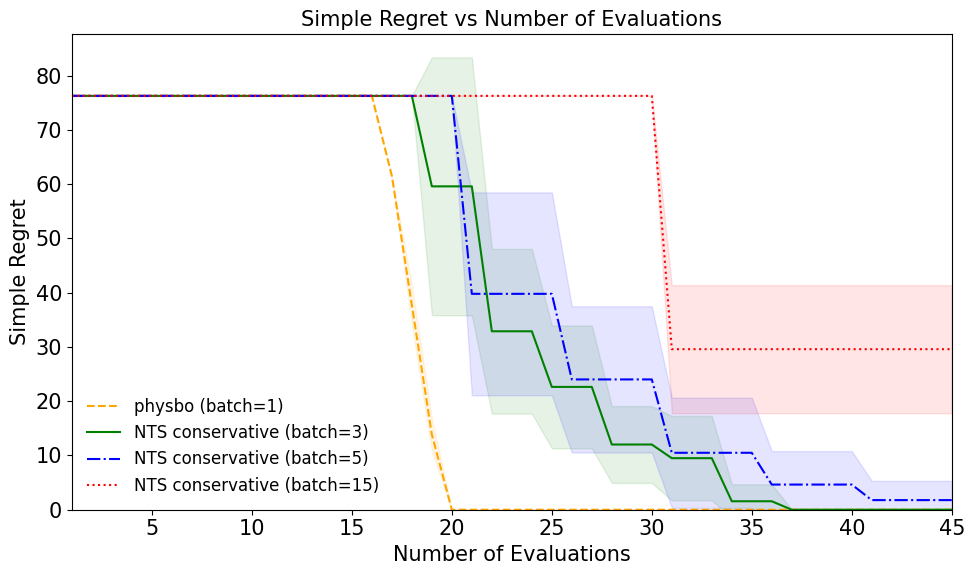

In [112]:
# Simple Regret vs Number of Evaluations (評価回数)
# 各バッチのregret値をバッチサイズ分繰り返して表示
INITIAL_BATCH_SIZE = 15

fig, ax = plt.subplots(figsize=(10, 6))

for label in method_to_regrets:
    if len(method_to_regrets[label]) == 0:
        continue
    batch_size = method_to_batch_size[label]
    regrets_array = np.array(method_to_regrets[label])  # shape: (trials, iterations)
    
    # 最初のregretだけはINITIAL_BATCH_SIZE回繰り返す
    first_regret = regrets_array[:, :1]  # shape: (trials, 1)
    initial_expanded = np.repeat(first_regret, INITIAL_BATCH_SIZE, axis=1)  # shape: (trials, 15)
    
    # 残りのregretはbatch_size回繰り返す
    remaining_regrets = regrets_array[:, 1:]  # shape: (trials, iterations-1)
    remaining_expanded = np.repeat(remaining_regrets, batch_size, axis=1)
    
    expanded_regrets = np.concatenate([initial_expanded, remaining_expanded], axis=1)
    print(f"{label}: expanded_regrets.shape = {expanded_regrets.shape}")
    
    mean_regrets = np.mean(expanded_regrets, axis=0)
    std_regrets = np.std(expanded_regrets, axis=0)
    
    # 評価回数 = 1, 2, 3, ...
    evaluations = np.arange(1, len(mean_regrets)+1)
    
    ax.plot(evaluations, mean_regrets, label=label, 
            linestyle=method_to_style[label], color=method_to_color[label])
    ax.fill_between(evaluations, mean_regrets - std_regrets, 
                    mean_regrets + std_regrets, alpha=0.1, color=method_to_color[label])

ax.set_xlabel("Number of Evaluations", fontsize=15)
ax.set_ylabel("Simple Regret", fontsize=15)
ax.set_title("Simple Regret vs Number of Evaluations", fontsize=15)
ax.set_ylim(0)
ax.set_xlim(1, 45)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("figures/simple_regret_vs_evaluations.pdf")
plt.show()

In [73]:
np.__version__

'2.4.2'

Circles AUC summary:
------------------------------------------------------------
physbo (batch=1): 179.80 ± 3.04
NTS conservative (batch=3): 176.10 ± 6.71
NTS conservative (batch=5): 177.50 ± 10.42
NTS conservative (batch=15): 161.50 ± 25.18


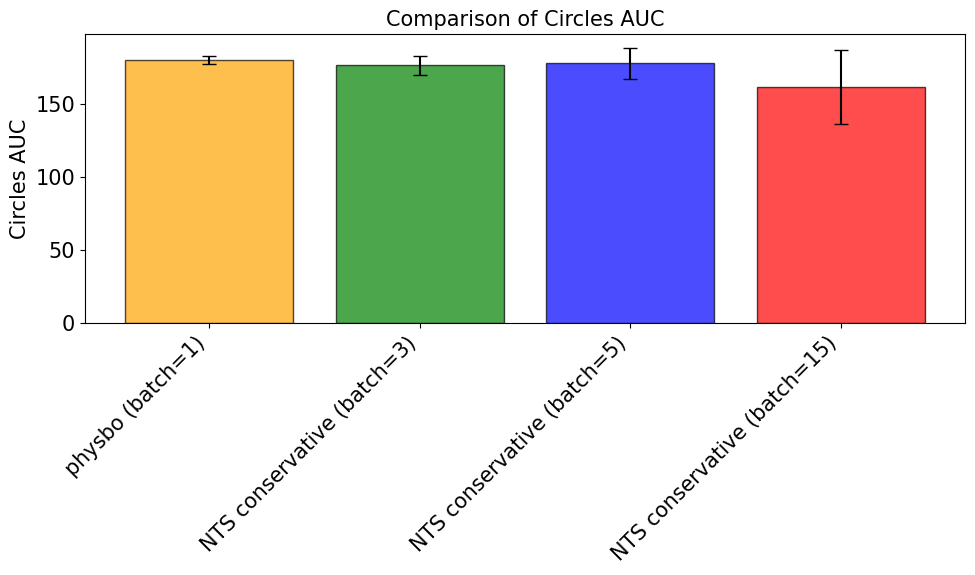

In [113]:
# Circles AUC (曲線下面積) の比較
trapz_dict = defaultdict(list)
for label in method_to_circles:
    if len(method_to_circles[label]) == 0:
        continue
    for circles in method_to_circles[label]:
        trapz_dict[label].append(np.trapezoid(circles, radius_list))

print("Circles AUC summary:")
print("-" * 60)
for label in trapz_dict:
    mean_val = np.mean(trapz_dict[label])
    std_val = np.std(trapz_dict[label])
    print(f"{label}: {mean_val:.2f} ± {std_val:.2f}")

# Bar plot
if len(trapz_dict) > 0:
    labels = list(trapz_dict.keys())
    means = [np.mean(trapz_dict[label]) for label in labels]
    stds = [np.std(trapz_dict[label]) for label in labels]
    colors = [method_to_color[label] for label in labels]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(range(len(labels)), means, yerr=stds, capsize=5, 
                  color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel("Circles AUC", fontsize=15)
    ax.set_title("Comparison of Circles AUC", fontsize=15)
    plt.tight_layout()
    plt.savefig("figures/circles_auc_comparison.pdf")
    plt.show()

In [114]:
# Summary statistics
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\nTarget threshold: {p}th percentile = {target_threshold:.4f}")
print(f"Number of iterations: {N}")
print(f"Number of trials per method: {len(trial_list)}")
print("\n")

print("Final Simple Regret (at last iteration):")
print("-" * 50)
for label in method_to_regrets:
    if len(method_to_regrets[label]) == 0:
        continue
    final_regrets = [r[-1] for r in method_to_regrets[label]]
    print(f"{label}: {np.mean(final_regrets):.4f} ± {np.std(final_regrets):.4f}")

SUMMARY

Target threshold: 90th percentile = 839.9850
Number of iterations: 30
Number of trials per method: 5


Final Simple Regret (at last iteration):
--------------------------------------------------
physbo (batch=1): 0.0000 ± 0.0000
NTS conservative (batch=3): 0.0000 ± 0.0000
NTS conservative (batch=5): 1.7720 ± 3.5440
NTS conservative (batch=15): 29.5860 ± 11.8045


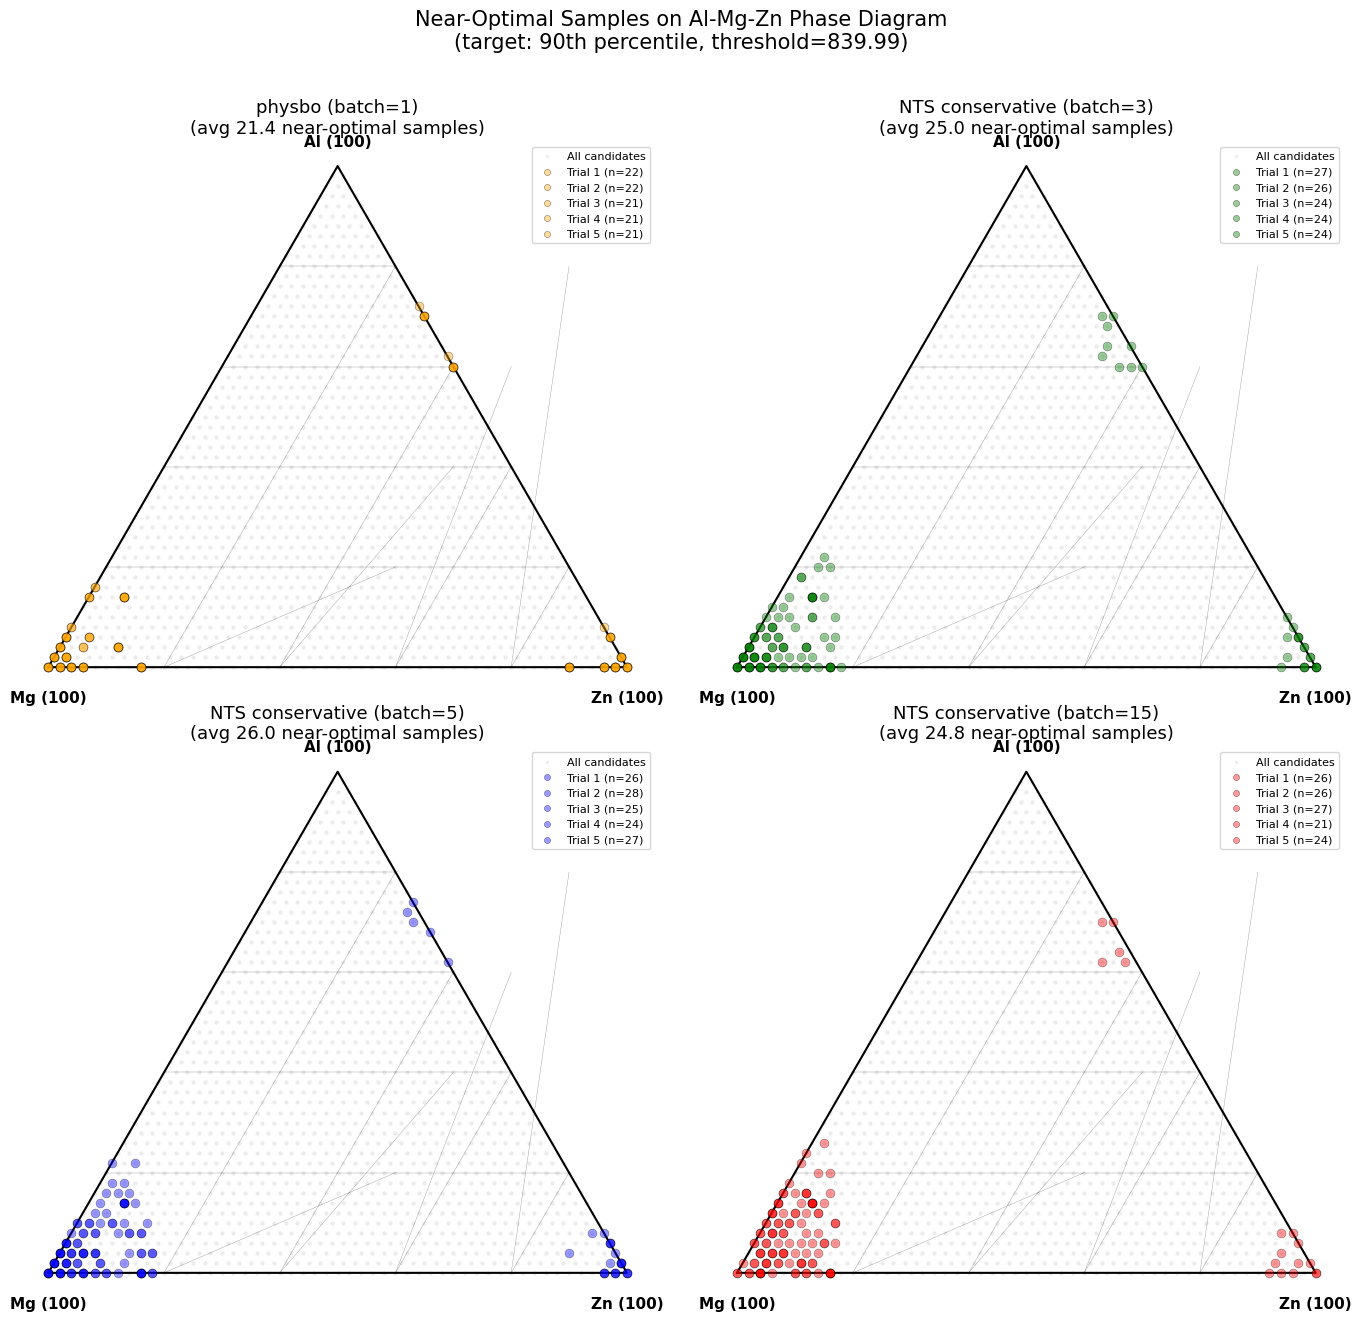

In [115]:
# 三元系のPhase Diagram上に、見つかったnear optimal samples をプロットし、可視化

def ternary_coords(mg, zn):
    """(Mg, Zn) → 三角図のCartesian座標に変換。
    頂点: Mg=bottom-left(0,0), Zn=bottom-right(1,0), Al=top(0.5, √3/2)"""
    mg, zn = np.asarray(mg, dtype=float), np.asarray(zn, dtype=float)
    al = 100 - mg - zn
    mg_f, zn_f, al_f = mg / 100, zn / 100, al / 100
    x = zn_f + al_f * 0.5
    y = al_f * np.sqrt(3) / 2
    return x, y

def draw_ternary_frame(ax):
    """三角ダイアグラムの枠・グリッド・ラベルを描画"""
    s3 = np.sqrt(3) / 2
    # 三角形の枠
    tri = np.array([[0, 0], [1, 0], [0.5, s3], [0, 0]])
    ax.plot(tri[:, 0], tri[:, 1], 'k-', lw=1.5)
    # 頂点ラベル
    ax.text(0, -0.04, 'Mg (100)', ha='center', va='top', fontsize=11, fontweight='bold')
    ax.text(1, -0.04, 'Zn (100)', ha='center', va='top', fontsize=11, fontweight='bold')
    ax.text(0.5, s3 + 0.03, 'Al (100)', ha='center', va='bottom', fontsize=11, fontweight='bold')
    # グリッド線 (20%刻み)
    for f in [0.2, 0.4, 0.6, 0.8]:
        # Al=const (Mg-Zn辺に平行)
        ax.plot([f*0.5, 1 - f*0.5], [f*s3, f*s3], 'k-', lw=0.3, alpha=0.4)
        # Mg=const (Zn-Al辺に平行)
        ax.plot([1-f, 0.5 + (1-f)*0.5], [0, (1-f)*s3], 'k-', lw=0.3, alpha=0.4)
        # Zn=const (Mg-Al辺に平行)
        ax.plot([f, f + (1-f)*0.5], [0, (1-f)*s3], 'k-', lw=0.3, alpha=0.4)
    ax.set_aspect('equal')
    ax.axis('off')

# --- Near-optimal サンプルの収集 ---
method_to_near_optimal = defaultdict(list)

for label, mode, batch_size in method_configs:
    for trial in trial_list:
        data_dir = dir_template.substitute(MODE=mode, BATCH_SIZE=batch_size, TRIAL=trial)
        sample_path = Path(data_dir) / "sample_by_iter.pkl"
        objective_path = Path(data_dir) / "objective_by_iter.pkl"
        if not sample_path.exists():
            continue
        with open(sample_path, 'rb') as f:
            samples_dict = pickle.load(f)
        with open(objective_path, 'rb') as f:
            objectives_dict = pickle.load(f)
        near_optimal = collect_near_optimal_samples(
            samples_dict, objectives_dict, target_threshold, N
        )
        n = len(near_optimal)
        method_to_near_optimal[label].append(near_optimal[n - 1])

# --- 背景: 全探索空間 ---
bg_x, bg_y = ternary_coords(des.X[:, 0], des.X[:, 1])

# --- プロット (2×2 subplots) ---
n_methods = len(method_configs)
ncols = 2
nrows = (n_methods + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6.5 * nrows))
axes = np.array(axes).flatten()

for idx, (label, mode, batch_size) in enumerate(method_configs):
    ax = axes[idx]
    draw_ternary_frame(ax)
    # 全候補点（灰色背景）
    ax.scatter(bg_x, bg_y, c='lightgray', s=5, alpha=0.3, zorder=1, label='All candidates')
    # 各trialのnear-optimalサンプルを重ねてプロット
    if label in method_to_near_optimal and len(method_to_near_optimal[label]) > 0:
        total_counts = []
        for t_idx, samples in enumerate(method_to_near_optimal[label]):
            if len(samples) > 0:
                arr = np.array(samples)
                sx, sy = ternary_coords(arr[:, 0], arr[:, 1])
                lbl = f'Trial {t_idx+1} (n={len(samples)})' 
                ax.scatter(sx, sy, c=method_to_color[label], s=40, alpha=0.4,
                          edgecolors='black', linewidth=0.5, zorder=2, label=lbl)
                total_counts.append(len(samples))
        mean_n = np.mean(total_counts) if total_counts else 0
        ax.set_title(f"{label}\n(avg {mean_n:.1f} near-optimal samples)", fontsize=13)
    else:
        ax.set_title(f"{label}\n(no data)", fontsize=13)
    ax.legend(fontsize=8, loc='upper right', framealpha=0.8, markerscale=0.7)

# 余ったsubplotを非表示
for idx in range(n_methods, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(f"Near-Optimal Samples on Al-Mg-Zn Phase Diagram\n(target: {p}th percentile, threshold={target_threshold:.2f})",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f"figures/phase_diagram_near_optimal_{p}percentile.pdf", bbox_inches='tight')
plt.show()

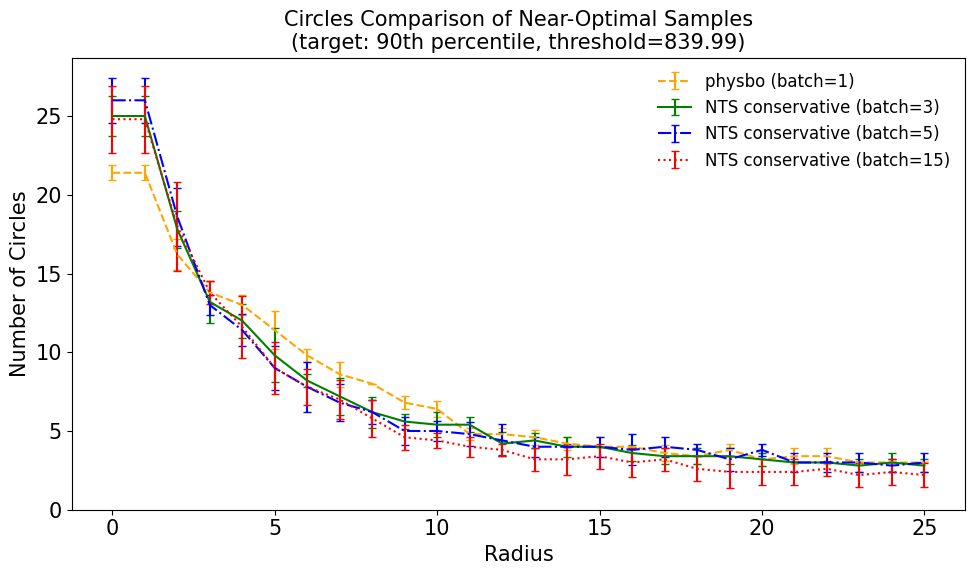

In [116]:
# 各手法のnear-optimal samplesについて、全閾値でCirclesを計算し比較
method_to_circles_from_near_optimal = defaultdict(list)

for label in method_to_near_optimal:
    for samples in method_to_near_optimal[label]:
        if len(samples) > 0:
            circles = circles_by_radius(samples, radius_list)
            method_to_circles_from_near_optimal[label].append(circles)

# 1つのグラフで全手法を比較
fig, ax = plt.subplots(figsize=(10, 6))

for label in method_to_circles_from_near_optimal:
    if len(method_to_circles_from_near_optimal[label]) == 0:
        continue
    arr = np.array(method_to_circles_from_near_optimal[label])
    mean_circles = np.mean(arr, axis=0)
    std_circles = np.std(arr, axis=0)
    ax.errorbar(radius_list, mean_circles, yerr=std_circles,
                label=label, linestyle=method_to_style[label],
                color=method_to_color[label], capsize=3)

ax.set_xlabel("Radius", fontsize=15)
ax.set_ylabel("Number of Circles", fontsize=15)
ax.set_title(f"Circles Comparison of Near-Optimal Samples\n(target: {p}th percentile, threshold={target_threshold:.2f})", fontsize=15)
ax.set_ylim(0)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig(f"figures/circles_near_optimal_comparison_{p}percentile.pdf", bbox_inches='tight')
plt.show()

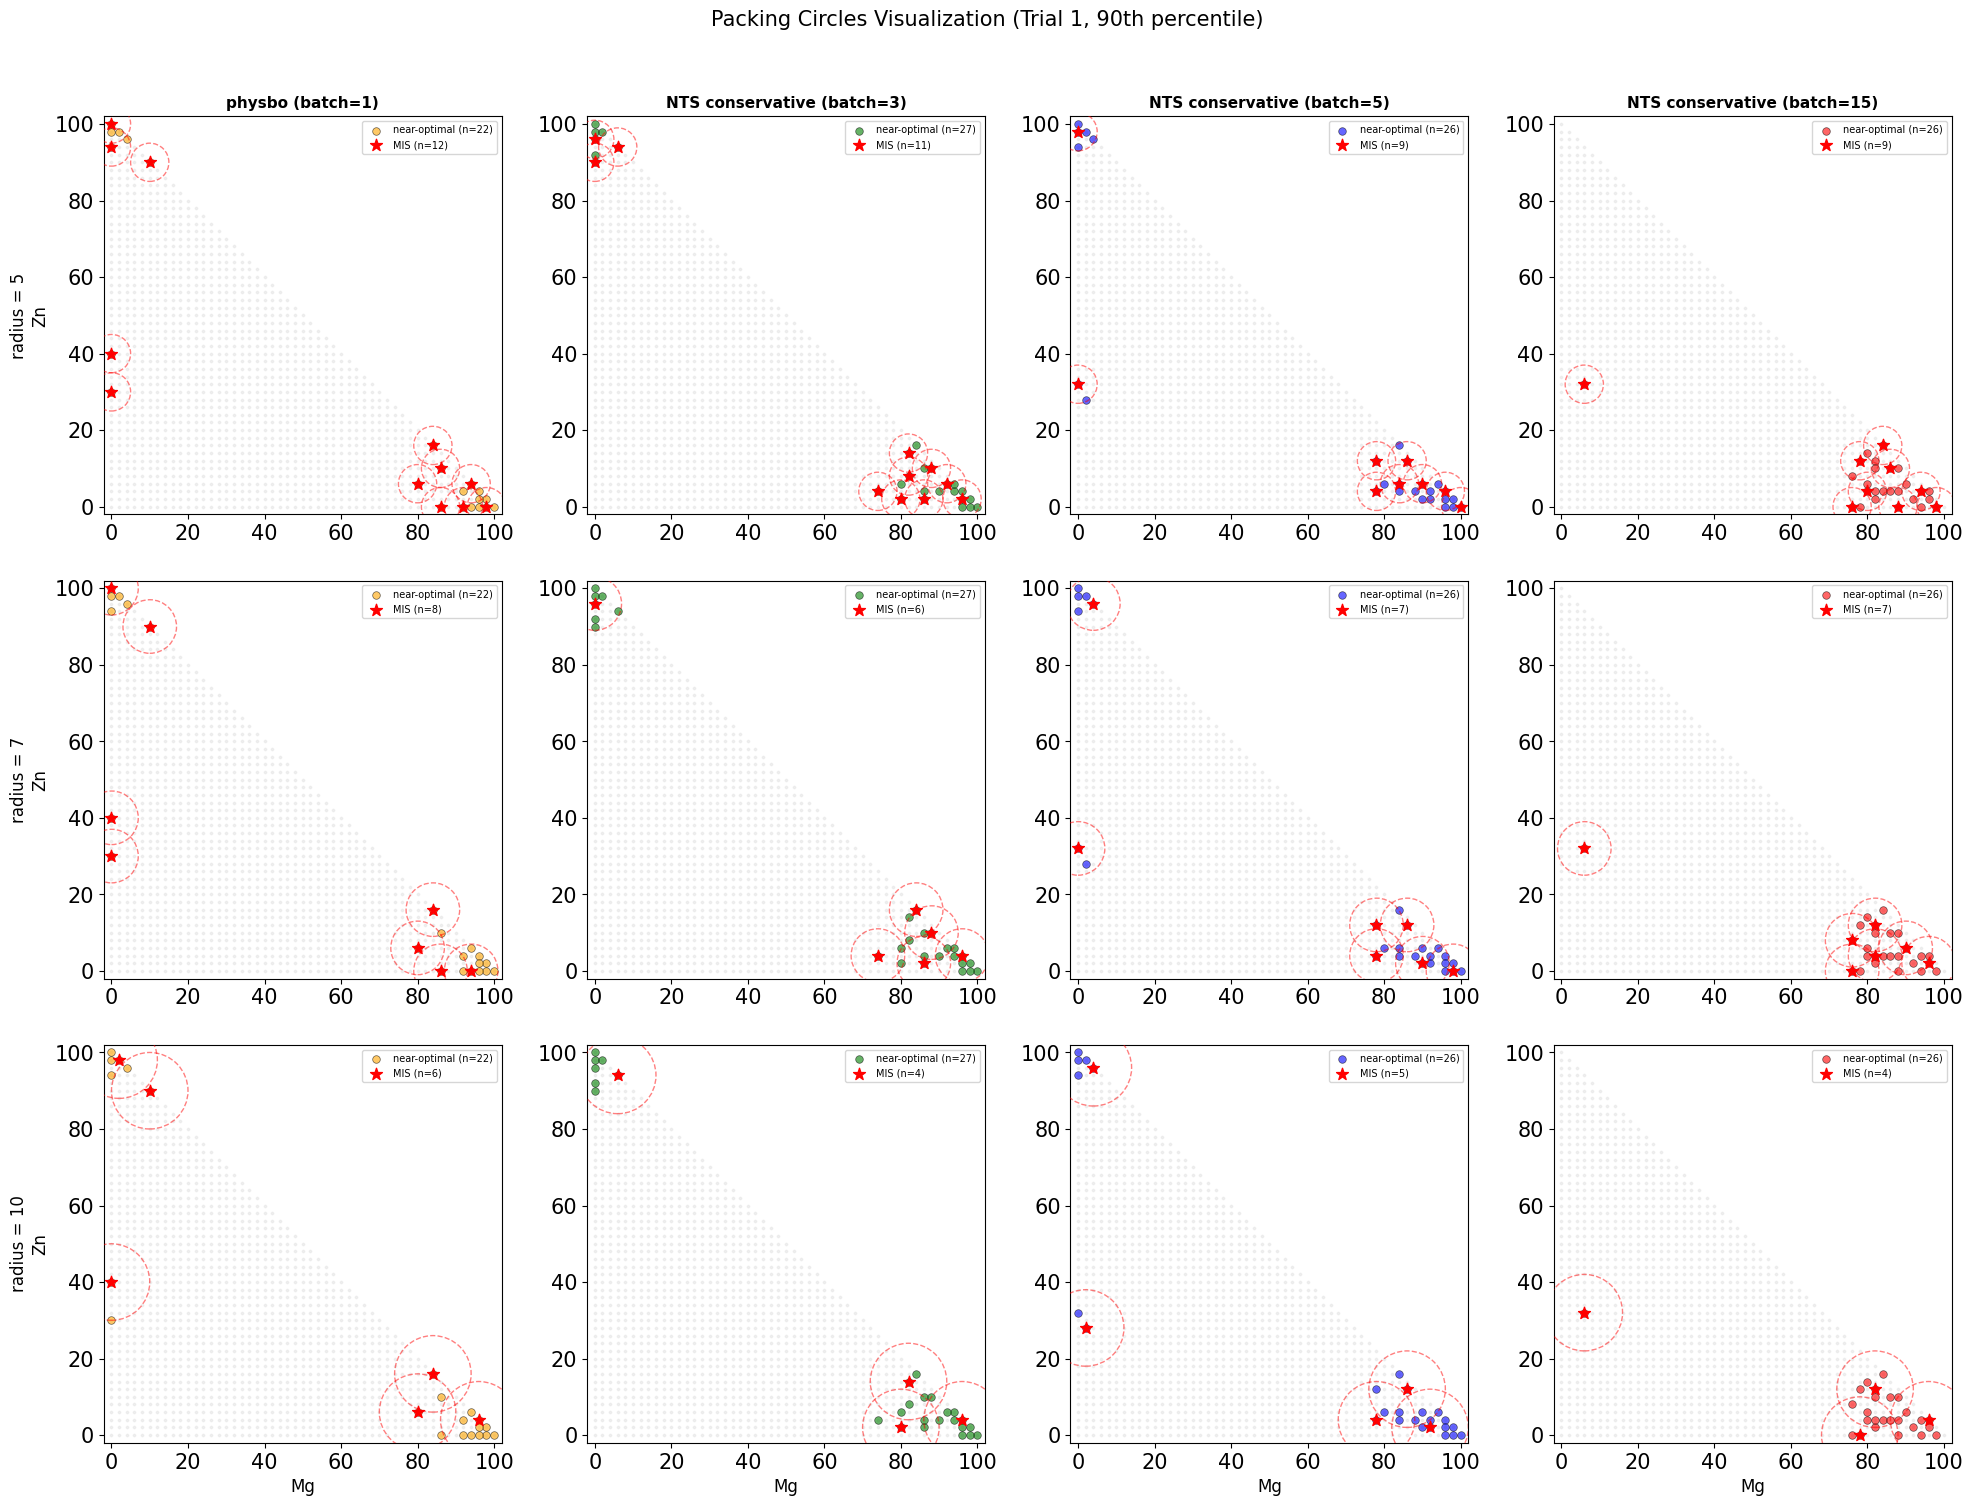

In [118]:
# Circlesの可視化: near-optimal samples上にpacking circlesを描画
# radius=5, 7, 10 の3つで各手法を比較 (trial 1のみ使用)

from matplotlib.patches import Circle as MplCircle

vis_radii = [5, 7, 10]
trial_idx = 0  # trial 1 を使用

fig, axes = plt.subplots(len(vis_radii), len(method_configs), 
                         figsize=(5 * len(method_configs), 5 * len(vis_radii)))

for ri, radius in enumerate(vis_radii):
    for mi, (label, mode, batch_size) in enumerate(method_configs):
        ax = axes[ri, mi]
        
        # 全探索空間を背景にプロット
        ax.scatter(des.X[:, 0], des.X[:, 1], c='lightgray', s=3, alpha=0.3, zorder=1)
        
        # near-optimal samples
        samples = method_to_near_optimal[label][trial_idx]
        if len(samples) == 0:
            ax.set_title(f"{label}\nradius={radius} (no samples)", fontsize=10)
            continue
        
        X_no = np.array(samples)
        ax.scatter(X_no[:, 0], X_no[:, 1], c=method_to_color[label], s=30, 
                   alpha=0.6, edgecolors='black', linewidth=0.5, zorder=3,
                   label=f'near-optimal (n={len(X_no)})')
        
        # Maximal Independent Set を計算
        D = pairwise_distances(X_no, metric="euclidean")
        mis_indices = maximal_independent_set(D, radius)
        X_mis = X_no[mis_indices]
        
        # MIS点をハイライト
        ax.scatter(X_mis[:, 0], X_mis[:, 1], c='red', s=80, marker='*', 
                   zorder=5, label=f'MIS (n={len(X_mis)})')
        
        # 各MIS点にcircleを描画 (radius が距離閾値なので、円の半径もradius)
        # MISのmaximality: 全ての非MIS点は少なくとも1つのMIS点から距離 radius 以内
        for cx, cy in X_mis:
            circle = MplCircle((cx, cy), radius, fill=False, 
                              edgecolor='red', linewidth=1.0, alpha=0.5, 
                              linestyle='--', zorder=4)
            ax.add_patch(circle)
        
        ax.set_xlim(-2, des.X[:, 0].max() + 2)
        ax.set_ylim(-2, des.X[:, 1].max() + 2)
        ax.set_aspect('equal')
        ax.legend(fontsize=7, loc='upper right')
        
        if ri == 0:
            ax.set_title(f"{label}", fontsize=11, fontweight='bold')
        if mi == 0:
            ax.set_ylabel(f"radius = {radius}\nZn", fontsize=12)
        if ri == len(vis_radii) - 1:
            ax.set_xlabel("Mg", fontsize=12)

fig.suptitle(f"Packing Circles Visualization (Trial 1, {p}th percentile)", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f"figures/circles_visualization_{p}percentile.pdf", bbox_inches='tight')
plt.show()